In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from trianglechain import TriangleChain

from msfm.utils import files
from msi.utils.ppc import PosteriorPredictiveChecks

2026-01-30 10:11:05.413122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# load data

### v14

In [3]:
base_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended"
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
wl_dir = os.path.join(base_dir, "lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default")
wl_steps = 400_000

# classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
gc_dir = os.path.join(base_dir, "clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default")
gc_steps = 240_000

# Posterior predictive distribution

## Auto-probe goodness of fit
lensing
$$s_{wl}^{rep} \sim p(s_{wl} | s_{wl}^{obs}) = \int d\theta p(s_{wl} | \theta) p(\theta | s_{wl}^{obs})$$
clustering
$$s_{gc}^{rep} \sim p(s_{gc} | s_{gc}^{obs}) = \int d\theta p(s_{gc} | \theta) p(\theta | s_{gc}^{obs})$$

## Cross-probe consistency
lensing given clustering
$$s_{wl}^{rep} \sim p(s_{wl} | s_{gc}^{obs}) = \int d\theta p(s_{wl} | \theta, s_{gc}^{obs}) p(\theta | s_{gc}^{obs})$$
clustering given lensing
$$s_{gc}^{rep} \sim p(s_{gc} | s_{wl}^{obs}) = \int d\theta p(s_{gc} | \theta, s_{wl}^{obs}) p(\theta | s_{wl}^{obs})$$

In [4]:
ppc = PosteriorPredictiveChecks(
    conf=conf,
    wl_model_dir=wl_dir,
    wl_model_steps=wl_steps,
    gc_model_dir=gc_dir,
    gc_model_steps=gc_steps,
)

26-01-30 10:11:35       ppc.py INF   Loading weak lensing data 
26-01-30 10:11:35 input_output INF   Loading predictions from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_400000.h5 
26-01-30 10:11:35 input_output INF   Array shapes: 
26-01-30 10:11:35 input_output INF   fiducial/vali/pred = (40000, 12) 
26-01-30 10:11:35 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-30 10:11:35 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-30 10:11:35 input_output INF   grid/pred          = (2500, 80, 12) 
26-01-30 10:11:35 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-01-30 10:11:35 input_output INF   grid/i_example     = (2500, 80) 
26-01-30 10:11:35 input_output INF   grid/i_noise       = (2500, 80) 
26-01-30 10:11:35 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-30 10:11:35 preprocessin INF   Shapes after concatenation and selection: 
26-01-30 10:11:35 preprocessi

In [5]:
ppc.setup_flow(
    rep_probe="clustering", 
    # rep_probe="lensing",
    # obs_probe="lensing", 
    obs_probe="clustering", 
    independent_cross=False, 
    # train_flow=True, 
    train_flow=False, 
)

26-01-30 10:11:39       ppc.py INF   Conditioning on clustering and sampling in clustering summary space 
26-01-30 10:11:39       ppc.py INF   flow = p(s_gc | theta_gc) 
26-01-30 10:11:39 likelihood_b INF   Set up the model directory /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/ppc_auto/likelihood_flow 
26-01-30 10:11:39 likelihood_f INF   Initialized the normalizing flow 
26-01-30 10:11:40 likelihood_f INF   Running on device cuda with default float torch.float32 
26-01-30 10:11:40 likelihood_f INF   Loaded the model from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/ppc_auto/likelihood_flow/likelihood_flow.pt 


/global/u2/a/athomsen/multiprobe-simulation-inference/msi/flow_conductor/likelihood_flow.py:501: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.loa

26-01-30 10:11:44       ppc.py INF   post = p(theta_gc | s_gc) 


/global/homes/a/athomsen/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(


  0%|          | 0/21 [00:00<?, ?it/s]

26-01-30 10:11:49  plotting.py INF   Saved the plot to /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/ppc_auto/likelihood_flow/contours_Buzzard_3.png 
26-01-30 10:11:49       ppc.py INF   Generating 100000 neural samples of p(s_gc | theta_gc) flow 
26-01-30 10:12:08       ppc.py INF   Done sampling after 0:00:19.47 
26-01-30 10:12:09       ppc.py INF   Effective Sample Size (ESS) = 2.1 out of 200000 
26-01-30 10:12:09       ppc.py INF   Drawing 1000 samples from the grid with importance weights 
26-01-30 10:12:09       ppc.py INF   Obtained 17 unique samples out of 1000 samples 


  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

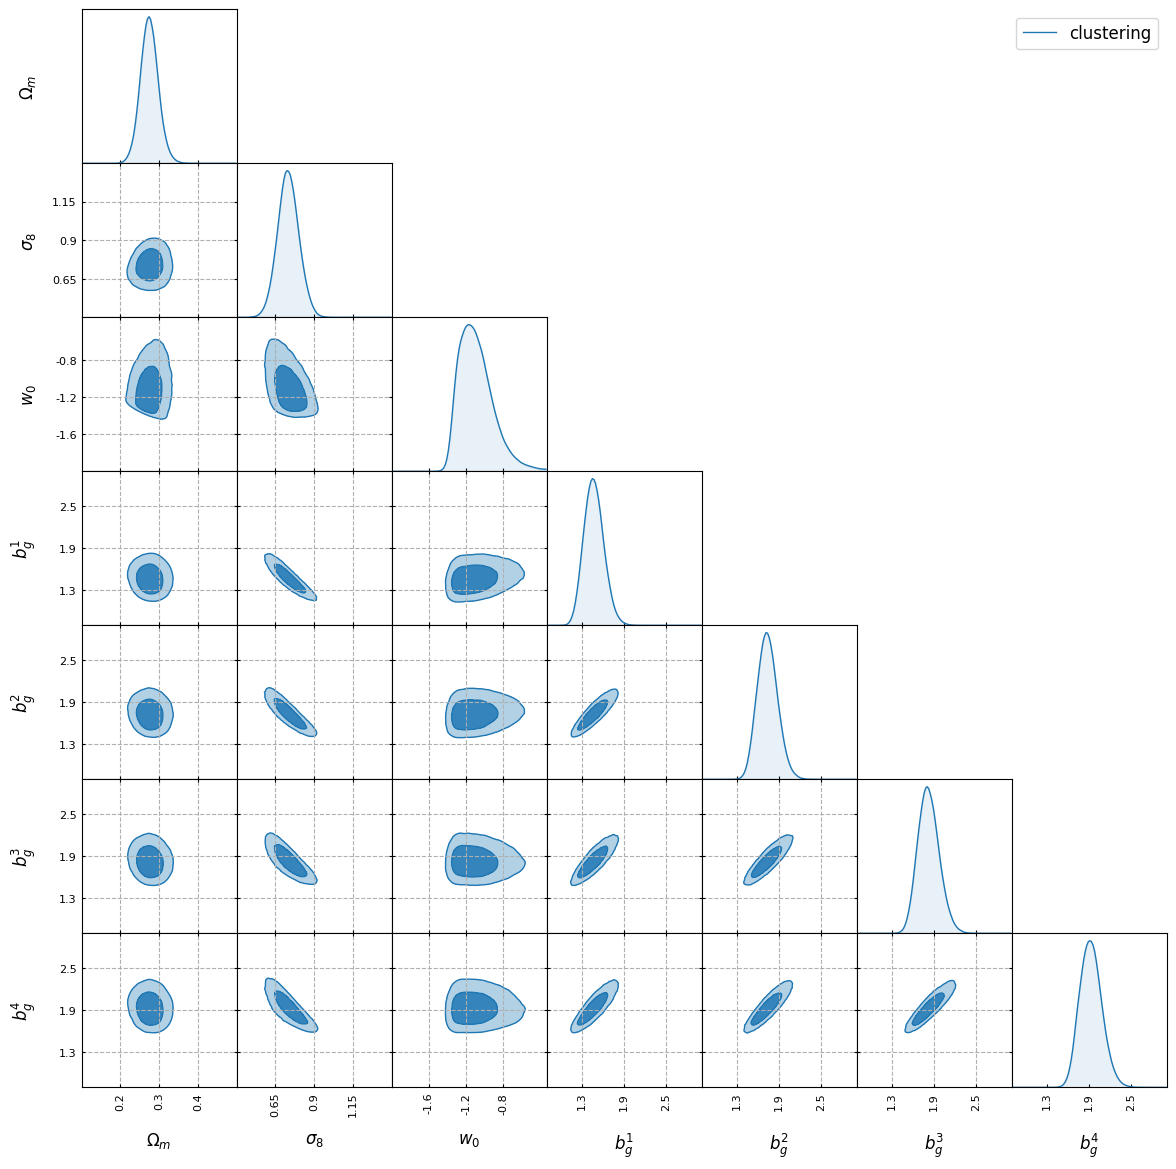

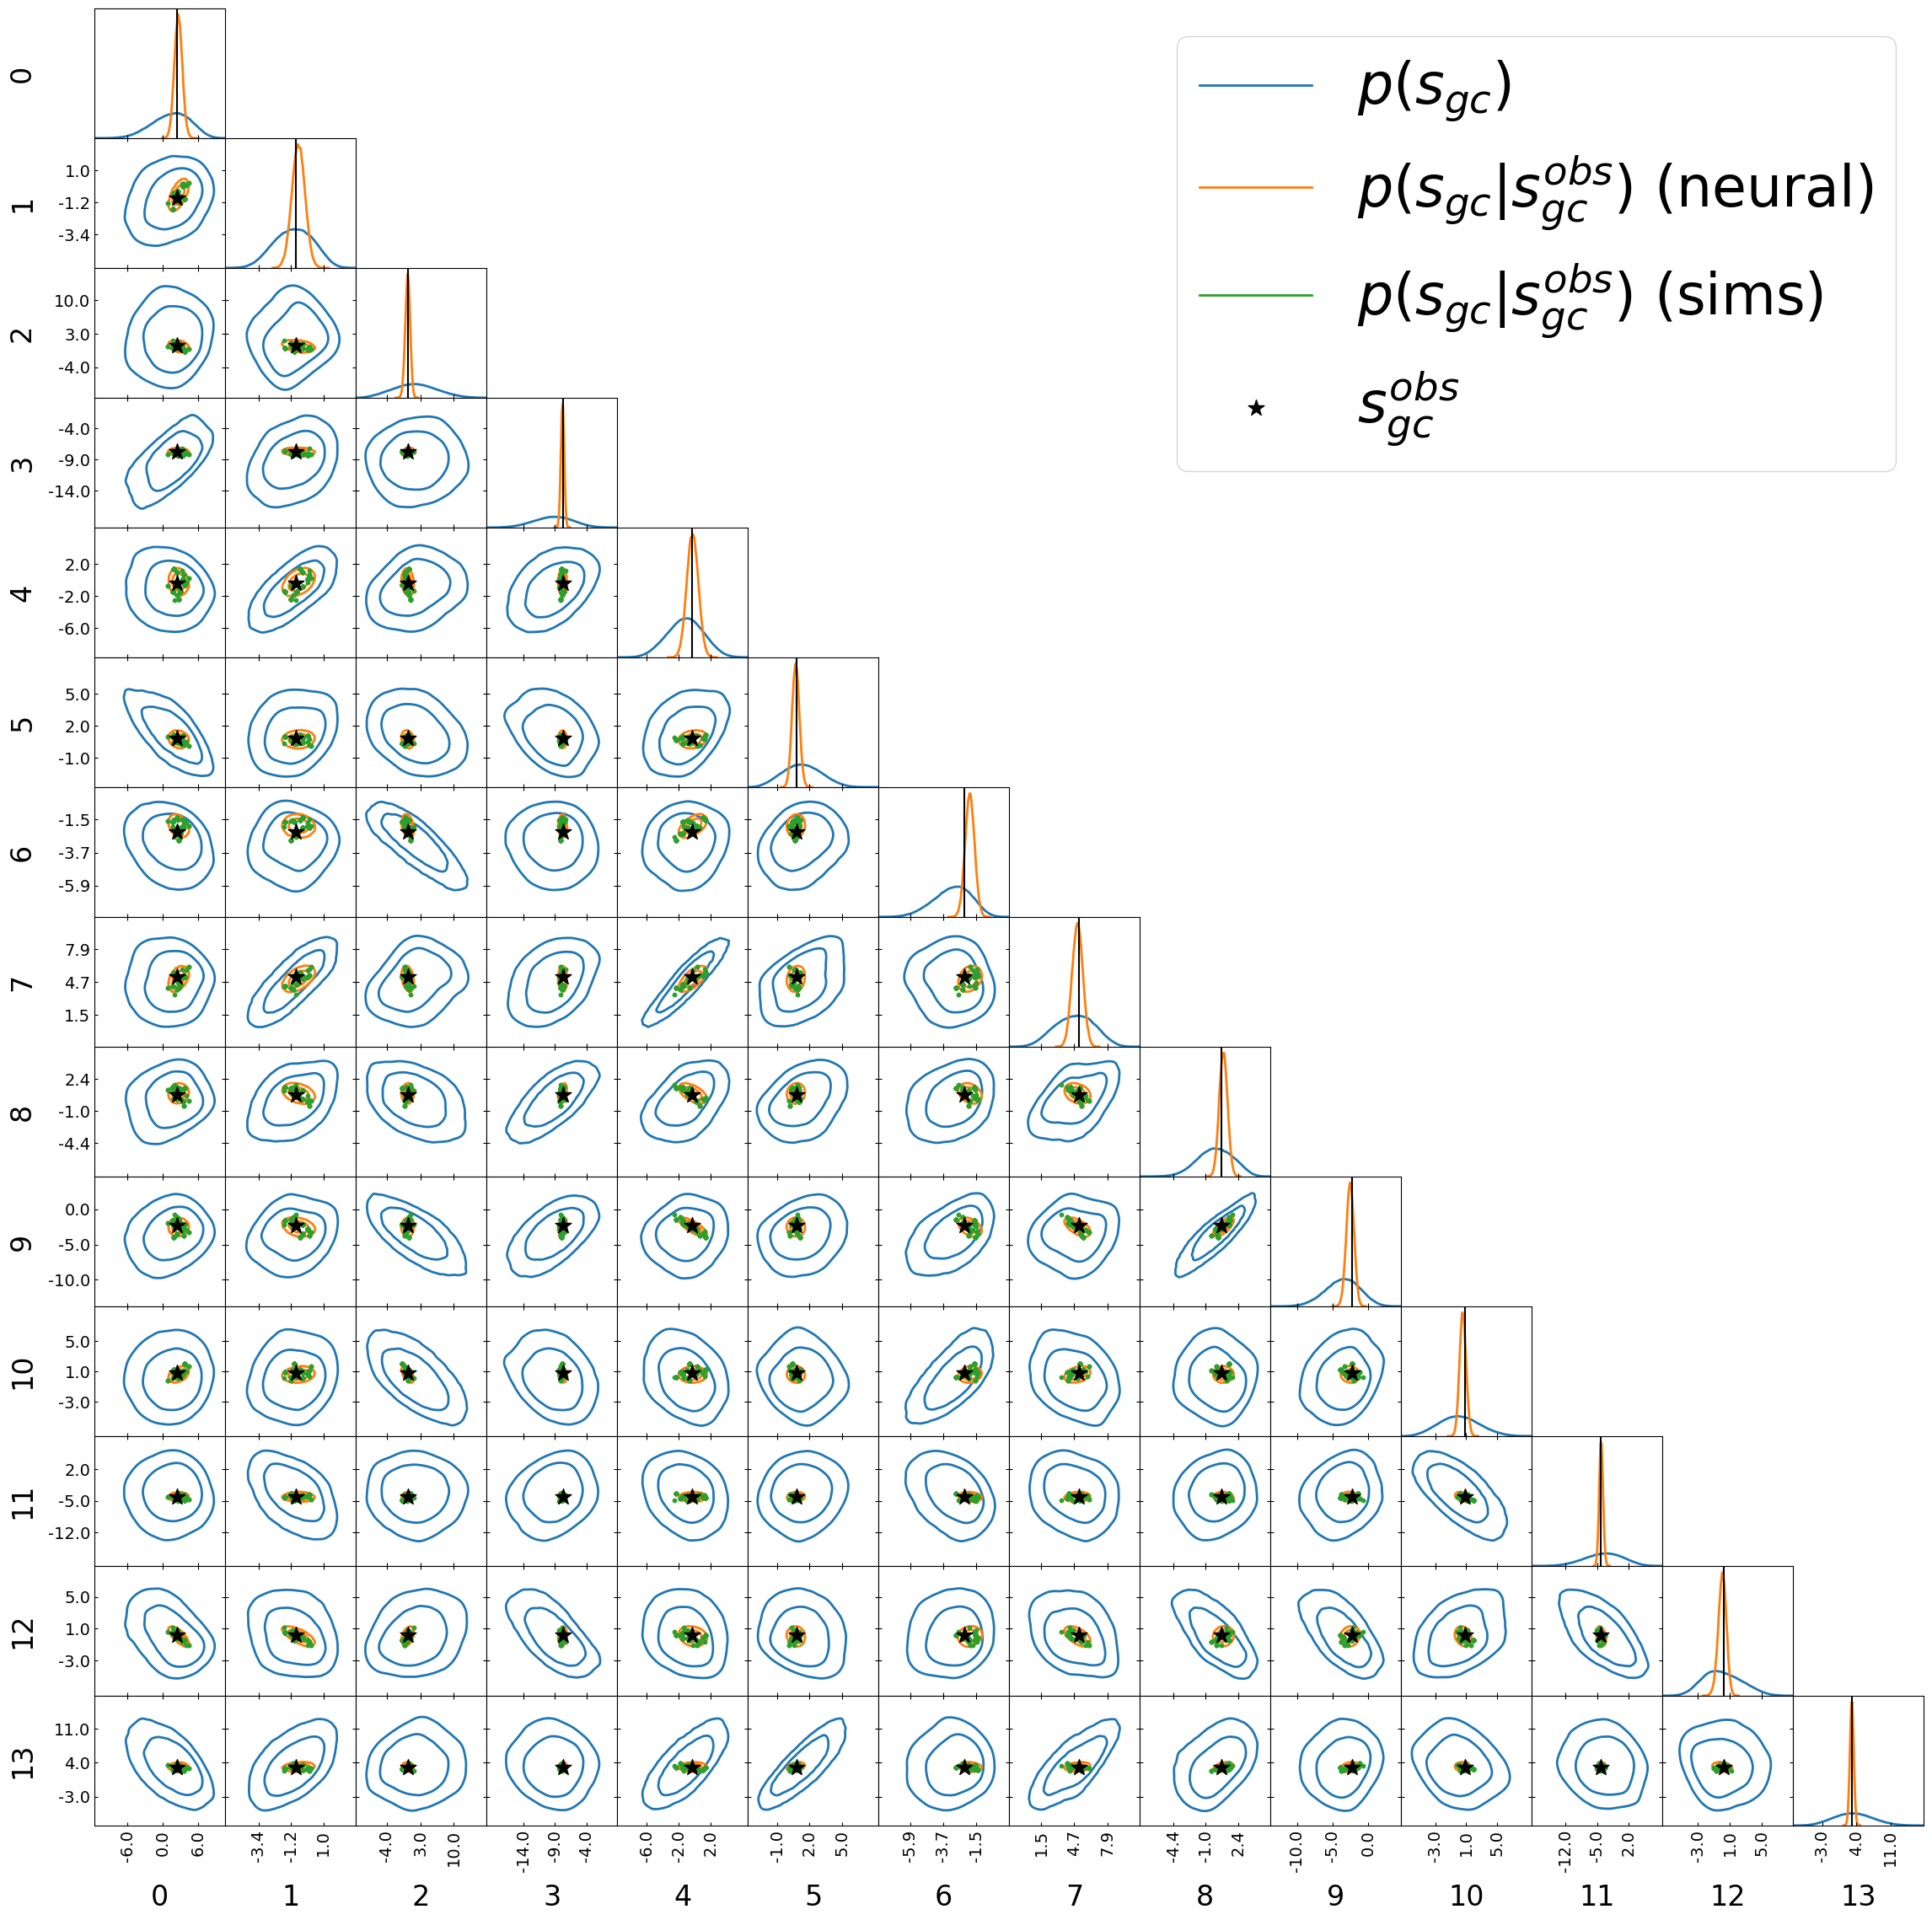

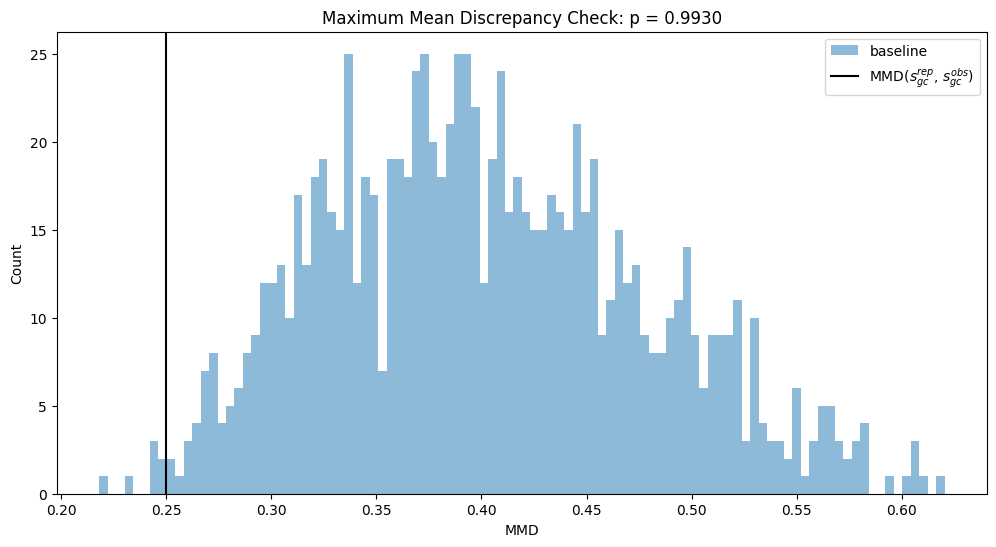

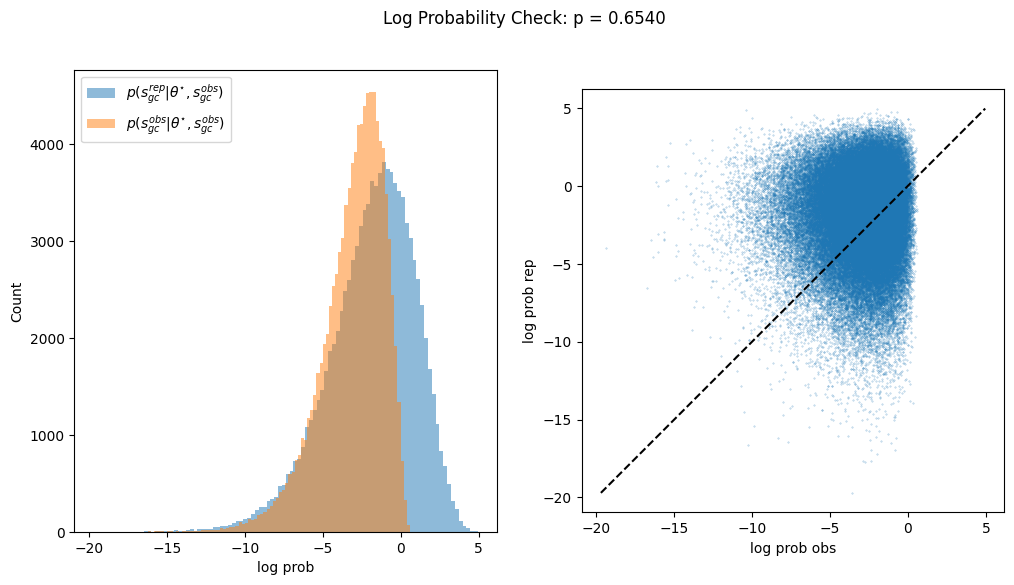

In [6]:
ppc.run_checks(
    obs_label="Buzzard_3",
)